# Fertilizer Recommendation with Tree-Based Models

This notebook builds a fertilizer recommendation model from soil conditions, crop type, and nutrient levels. It compares Decision Tree, Gradient Boosting Machine, and XGBoost classifiers, then uses the strongest model for fertilizer prediction.

## 1. Setup

Import the packages used for data analysis, plotting, preprocessing, model training, evaluation, and feature importance.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

Load the local dataset file included with this project.

In [2]:
DATA_PATH = 'data/fertilizer_prediction.csv'

fertilizer_df = pd.read_csv(DATA_PATH)
fertilizer_df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


## 3. Clean Column Names

Standardize column names before analysis. The source file has a trailing space in `Humidity ` and a spelling issue in `Temparature`.

In [3]:
fertilizer_df = fertilizer_df.rename(
    columns={
        'Temparature': 'Temperature',
        'Humidity ': 'Humidity',
        'Soil Type': 'Soil_Type',
        'Crop Type': 'Crop_Type',
        'Fertilizer Name': 'Fertilizer',
    }
)

fertilizer_df.head()

,Temperature,Humidity,Moisture,Soil_Type,Crop_Type,Nitrogen,Potassium,Phosphorous,Fertilizer
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


## 4. Data Check

Review dataset size, missing values, unique-value counts, and summary statistics before modeling.

In [4]:
print(f'Dataset shape: {fertilizer_df.shape}')
print('Columns:')
print(fertilizer_df.columns.tolist())

Dataset shape: (99, 9)
Columns:
['Temperature', 'Humidity', 'Moisture', 'Soil_Type', 'Crop_Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer']


In [5]:
missing_values = fertilizer_df.isna().sum()
missing_values

Temperature    0
Humidity       0
Moisture       0
Soil_Type      0
Crop_Type      0
Nitrogen       0
Potassium      0
Phosphorous    0
Fertilizer     0
dtype: int64

In [6]:
unique_value_counts = fertilizer_df.nunique().sort_values(ascending=False)
unique_value_counts

Moisture       41
Phosphorous    32
Nitrogen       24
Temperature    14
Humidity       13
Potassium      13
Crop_Type      11
Fertilizer      7
Soil_Type       5
dtype: int64

In [7]:
fertilizer_df.describe(include='all')

,Temperature,Humidity,Moisture,Soil_Type,Crop_Type,Nitrogen,Potassium,Phosphorous,Fertilizer
count,99.000000,99.000000,99.000000,99,99,99.000000,99.000000,99.000000,99
unique,NaN,NaN,NaN,5,11,NaN,NaN,NaN,7
top,NaN,NaN,NaN,Loamy,Sugarcane,NaN,NaN,NaN,Urea
freq,NaN,NaN,NaN,21,13,NaN,NaN,NaN,22
mean,30.282828,59.151515,43.181818,NaN,NaN,18.909091,3.383838,18.606061,NaN
std,3.502304,5.840331,11.271568,NaN,NaN,11.599693,5.814667,13.476978,NaN
min,25.000000,50.000000,25.000000,NaN,NaN,4.000000,0.000000,0.000000,NaN
25%,28.000000,54.000000,34.000000,NaN,NaN,10.000000,0.000000,9.000000,NaN
50%,30.000000,60.000000,41.000000,NaN,NaN,13.000000,0.000000,19.000000,NaN
75%,33.000000,64.000000,50.500000,NaN,NaN,24.000000,7.500000,30.000000,NaN


## 5. Fertilizer Class Balance

Check the distribution of fertilizer classes. The dataset is small, so class balance is useful context for model scores.

In [8]:
target_column = 'Fertilizer'
fertilizer_counts = fertilizer_df[target_column].value_counts()
fertilizer_counts

Fertilizer
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7
Name: count, dtype: int64

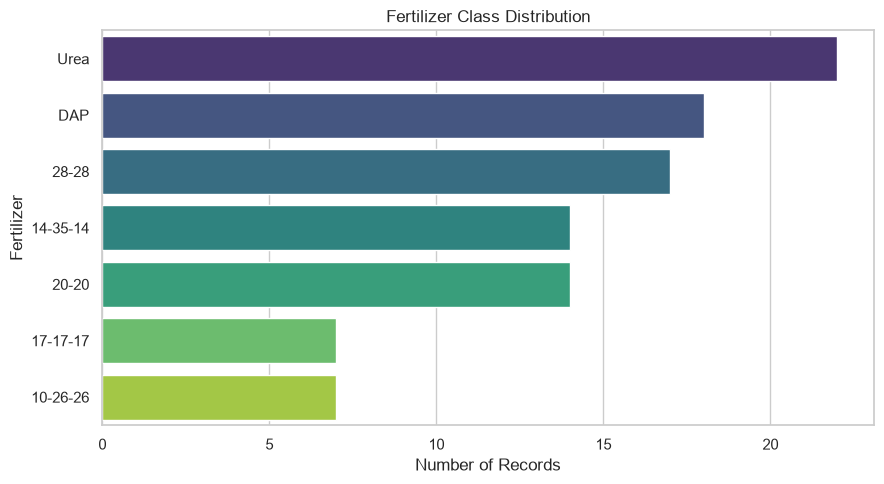

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(x=fertilizer_counts.values, y=fertilizer_counts.index, palette='viridis')
plt.title('Fertilizer Class Distribution')
plt.xlabel('Number of Records')
plt.ylabel('Fertilizer')
plt.tight_layout()
plt.show()

## 6. Exploratory Analysis

Inspect numeric feature distributions and category patterns related to fertilizer choice.

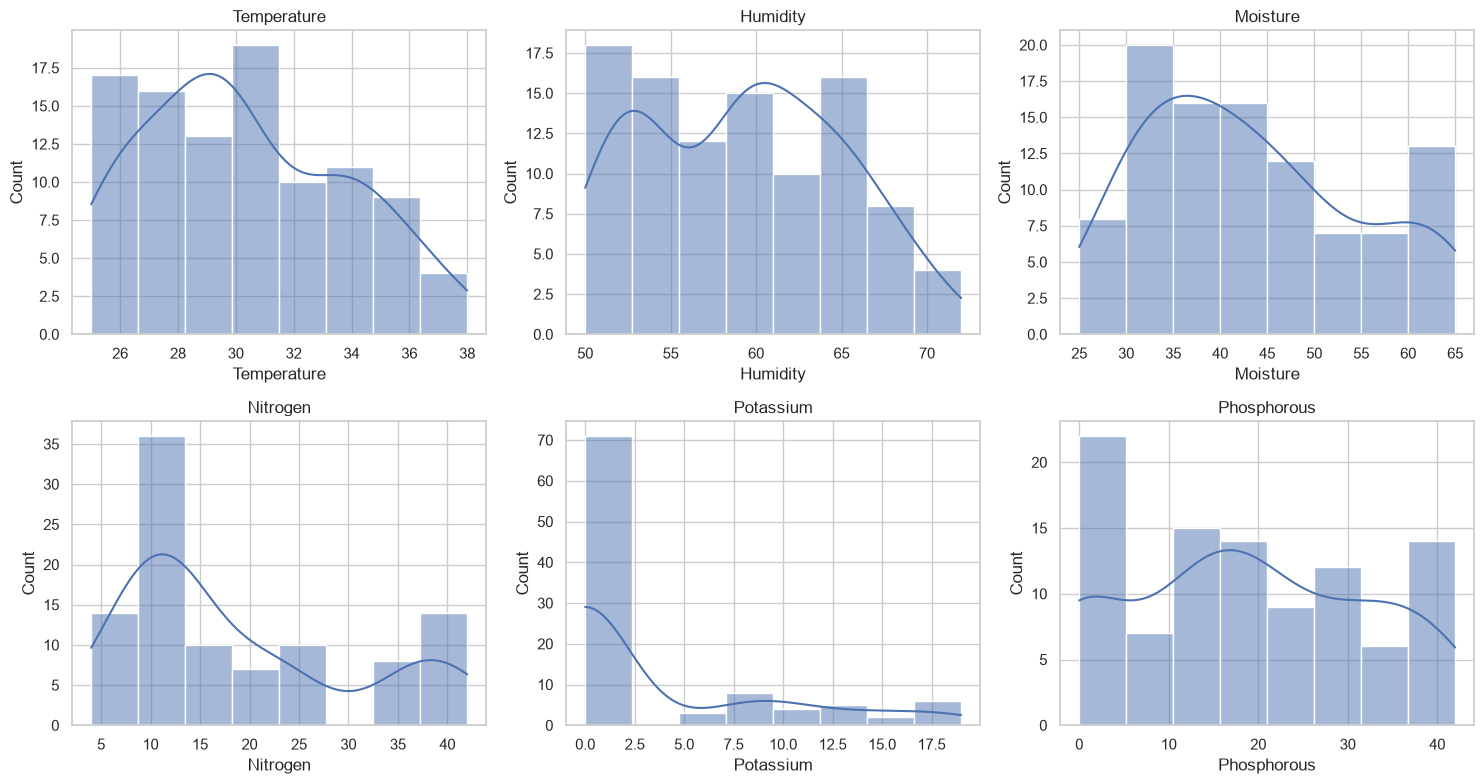

In [10]:
numeric_features = ['Temperature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
categorical_features = ['Soil_Type', 'Crop_Type']
feature_columns = numeric_features + categorical_features

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for axis, feature in zip(axes, numeric_features):
    sns.histplot(fertilizer_df[feature], kde=True, ax=axis)
    axis.set_title(feature)

plt.tight_layout()
plt.show()

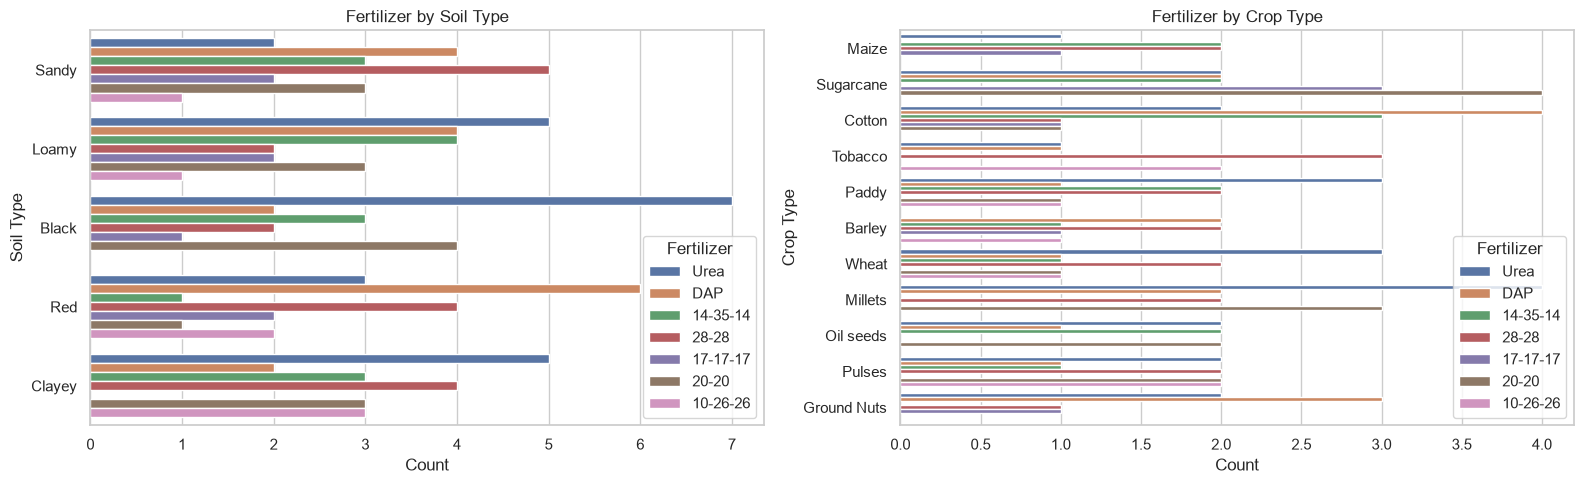

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=fertilizer_df, y='Soil_Type', hue=target_column, ax=axes[0])
axes[0].set_title('Fertilizer by Soil Type')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Soil Type')

sns.countplot(data=fertilizer_df, y='Crop_Type', hue=target_column, ax=axes[1])
axes[1].set_title('Fertilizer by Crop Type')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Crop Type')

plt.tight_layout()
plt.show()

## 7. Preprocessing and Train/Test Split

One-hot encode categorical fields and label-encode the target. XGBoost requires numeric class labels, so the encoded target is used for every model comparison.

In [12]:
model_features = fertilizer_df[feature_columns]
fertilizer_labels = fertilizer_df[target_column]

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(fertilizer_labels)

training_features, test_features, training_labels, test_labels = train_test_split(
    model_features,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='passthrough'
)

print(f'training_features shape: {training_features.shape}')
print(f'test_features shape: {test_features.shape}')

training_features shape: (79, 8)
test_features shape: (20, 8)


## 8. Model Comparison

Compare three tree-based classifiers: Decision Tree, Gradient Boosting Machine, and XGBoost. The workflow does not save trained models locally.

In [13]:
candidate_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting Machine': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        n_estimators=150,
        max_depth=3,
        learning_rate=0.08,
    ),
}

model_results = []
trained_pipelines = {}
test_predictions = {}

for model_name, classifier in candidate_models.items():
    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', classifier),
        ]
    )
    model_pipeline.fit(training_features, training_labels)
    predicted_labels = model_pipeline.predict(test_features)

    trained_pipelines[model_name] = model_pipeline
    test_predictions[model_name] = predicted_labels
    model_results.append(
        {
            'model': model_name,
            'accuracy': accuracy_score(test_labels, predicted_labels),
            'precision_weighted': precision_score(test_labels, predicted_labels, average='weighted', zero_division=0),
            'recall_weighted': recall_score(test_labels, predicted_labels, average='weighted', zero_division=0),
            'f1_weighted': f1_score(test_labels, predicted_labels, average='weighted', zero_division=0),
        }
    )

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(['accuracy', 'f1_weighted'], ascending=False)
    .reset_index(drop=True)
)

best_model_name = model_comparison.loc[0, 'model']
best_fertilizer_model = trained_pipelines[best_model_name]
best_model_predictions = test_predictions[best_model_name]

model_comparison

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,XGBoost,1.00,1.000000,1.00,1.000000
1,Decision Tree,0.95,0.975000,0.95,0.953333
2,Gradient Boosting Machine,0.95,0.958333,0.95,0.947273


## 9. Best Model Evaluation

Review the confusion matrix and class-level metrics for the best-performing model.

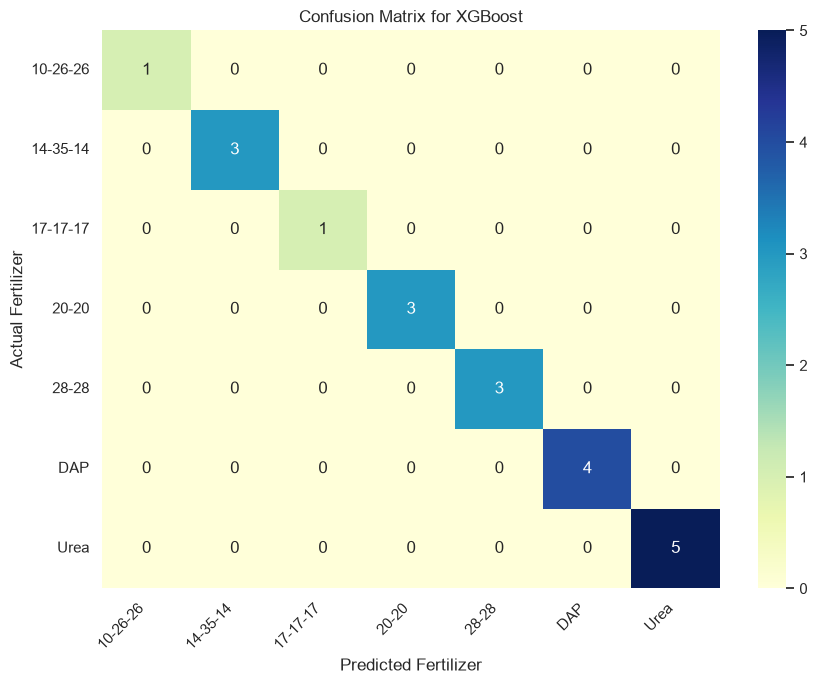

In [14]:
class_names = label_encoder.classes_
confusion_counts = confusion_matrix(test_labels, best_model_predictions)

plt.figure(figsize=(9, 7))
sns.heatmap(
    confusion_counts,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Fertilizer')
plt.ylabel('Actual Fertilizer')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
print(f'Best model: {best_model_name}')
print(classification_report(test_labels, best_model_predictions, target_names=class_names, zero_division=0))

Best model: XGBoost
              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      1.00      1.00         3
    17-17-17       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 10. Feature Importance

Rank the preprocessed input features by importance for the selected tree-based model.

In [16]:
preprocessed_feature_names = best_fertilizer_model.named_steps['preprocessor'].get_feature_names_out()
best_classifier = best_fertilizer_model.named_steps['classifier']

if hasattr(best_classifier, 'feature_importances_'):
    importance_values = best_classifier.feature_importances_
else:
    importance_values = np.zeros(len(preprocessed_feature_names))

feature_importance = (
    pd.DataFrame({
        'feature': preprocessed_feature_names,
        'importance': importance_values,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,feature,importance
0,remainder__Nitrogen,0.388003
1,remainder__Potassium,0.365618
2,remainder__Phosphorous,0.239194
3,remainder__Moisture,0.004958
4,remainder__Temperature,0.002228
5,categorical__Soil_Type_Black,0.000000
6,categorical__Crop_Type_Barley,0.000000
7,categorical__Soil_Type_Sandy,0.000000
8,categorical__Soil_Type_Red,0.000000
9,categorical__Soil_Type_Loamy,0.000000


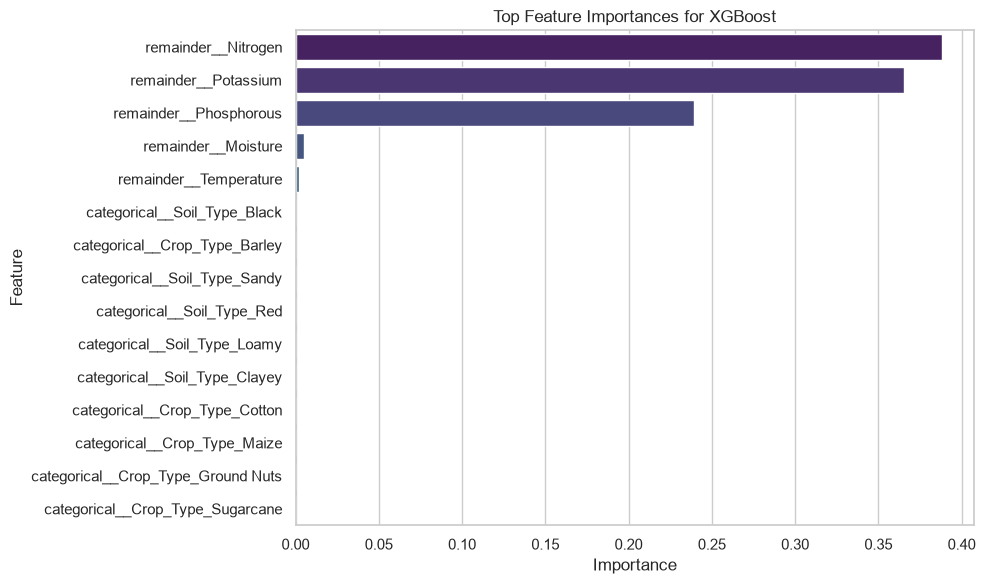

In [17]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title(f'Top Feature Importances for {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 11. Example Fertilizer Recommendation

Run one field profile through the best model and decode the predicted fertilizer label.

In [18]:
example_field_profile = pd.DataFrame(
    [
        {
            'Temperature': 30,
            'Humidity': 60,
            'Moisture': 40,
            'Nitrogen': 20,
            'Potassium': 0,
            'Phosphorous': 20,
            'Soil_Type': 'Loamy',
            'Crop_Type': 'Sugarcane',
        }
    ]
)

encoded_recommendation = best_fertilizer_model.predict(example_field_profile)
recommended_fertilizer = label_encoder.inverse_transform(encoded_recommendation)

print(f'Best model: {best_model_name}')
print(f'Recommended fertilizer: {recommended_fertilizer[0]}')

Best model: XGBoost
Recommended fertilizer: 28-28
